# Calculating Dynamic Modulus $G(t)$

For the purposes of classifying/observing the viscoelastic properties of the bulk polymer, we calculate a time averaged dynamic modulus $\bar G(t)$

$$G(t) = \frac V {k_B T} \langle \sigma_{xy}(t)\sigma_{xy}(0)\rangle$$

$$\bar G(t) = \frac 1 t \int_0^t G(t')dt'$$

(Raffaeli and Ellenbroek)

For smoother curves with more sampling, we average over all possible perpendicular axes,

$$G(t) = \frac V {5 k_BT}\left[\langle\sigma_{xy}(t)\sigma_{xy}(0)\rangle+\langle\sigma_{yz}(t)\sigma_{yz}(0)\rangle+\langle\sigma_{xz}(t)\sigma_{xz}(0)\rangle\right]\\ + \frac V {30 k_BT}\left[\langle N_{xy}(t) N_{xy}(0)\rangle+\langle N_{yz}(t) N_{yz}(0)\rangle+\langle N_{xz}(t) N_{xz}(0)\rangle\right]$$

Pressure from LAMMPS is in LJ units.

As noted in the the `compute stress/atom` docs, "per-atom stress is the negative of the per-atom pressure tensor." So, we can simply use the negative $xy$ component of pressure as the $xy$ component of the stress tensor.

However, this then means that 

$$C(t) = \langle (-p_{xy}(t))(-p_{xy}(0))\rangle$$
$$C(t) = \langle p_{xy}(t)p_{xy}(0)\rangle$$

so we can simply replace the stress terms with pressure terms.


## $G(t), \bar G(t)$ function definition

In [31]:
import numpy as np
import multipletau

def half_auto_corr(data):  
    """Compute the half autocorrelation of a 1D array."""
    auto_corr = np.correlate(data - np.mean(data), data - np.mean(data), mode='full')
    half_corr = auto_corr[auto_corr.size // 2:] / np.arange(len(data), 0, -1)
    return half_corr

def N_xy(x, y):
    """Compute the normal stress difference N_xy = P_xx - P_yy."""
    return x - y

def G_func(pxx, pyy, pzz, pxy, pxz, pyz, t, multitau=True):
    """
    Compute the shear relaxation modulus G(t) from stress tensor components.
    Parameters:
    pxx, pyy, pzz, pxy, pxz, pyz : 1D arrays of pressure (-ve stress) tensor components over time
    t : 1D array of time points
    Returns:
    G_t : 1D array of shear relaxation modulus G(t)
    t : 1D array of time points
    """
    kB = 1.0       # Boltzmann constant = 1 in LJ units
    T = 1.0        # temperature
    V = 40**3      # volume

    if multitau:
        auto_corr_Nxy = multipletau.autocorrelate(N_xy(pxx, pyy) - np.mean(N_xy(pxx, pyy)), deltat=(t[1]-t[0] * 0.001))[:, 1]
        auto_corr_Nxz = multipletau.autocorrelate(N_xy(pxx, pzz) - np.mean(N_xy(pxx, pzz)), deltat=(t[1]-t[0] * 0.001))[:, 1]
        auto_corr_Nyz = multipletau.autocorrelate(N_xy(pyy, pzz) - np.mean(N_xy(pyy, pzz)), deltat=(t[1]-t[0] * 0.001))[:, 1]
        auto_corr_xy = multipletau.autocorrelate(pxy - np.mean(pxy), deltat=(t[1]-t[0] * 0.001))[:, 1]
        auto_corr_xz = multipletau.autocorrelate(pxz - np.mean(pxz), deltat=(t[1]-t[0] * 0.001))[:, 1]
        auto_corr_yz = multipletau.autocorrelate(pyz - np.mean(pyz), deltat=(t[1]-t[0] * 0.001))

        t = auto_corr_yz[:, 0]
        auto_corr_yz = auto_corr_yz[:, 1]
    else:
        # average over all perpendicular axes
        auto_corr_Nxy = half_auto_corr(N_xy(pxx, pyy))
        auto_corr_Nxz = half_auto_corr(N_xy(pxx, pzz))
        auto_corr_Nyz = half_auto_corr(N_xy(pyy, pzz))
        auto_corr_xy = half_auto_corr(pxy)
        auto_corr_xz = half_auto_corr(pxz)
        auto_corr_yz = half_auto_corr(pyz)
    
    G_t = (auto_corr_xy + auto_corr_yz + auto_corr_xz) / 5.0 + \
            (auto_corr_Nxy + auto_corr_Nxz + auto_corr_Nyz) / 30.0

    G_t *= V / (kB * T)

    return G_t, t

def overline_G_func(pxx, pyy, pzz, pxy, pxz, pyz, t):
    G_t = G_func(pxx, pyy, pzz, pxy, pxz, pyz, t)[0]
    time = t
    dt = time[1] - time[0]

    overline_G = np.cumsum(G_t) * dt / time
    overline_G[0] = overline_G[1]  # avoid division by zero
    overline_G /= overline_G[0]  # normalize by G(0)
    
    return overline_G, time


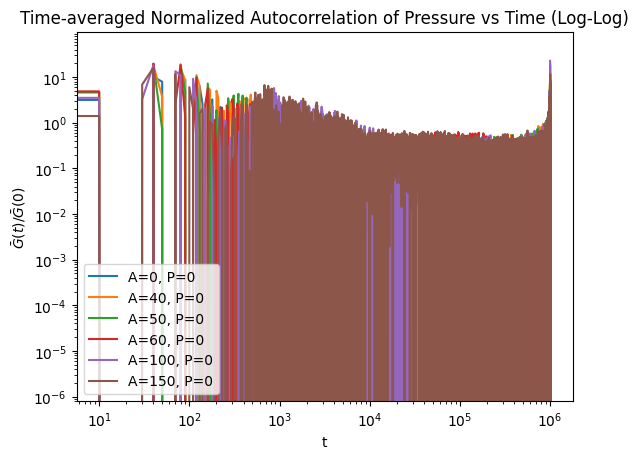

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

P_values=[0]
patch_A_strengths=[0, 40, 50, 60, 100, 150]

for P in P_values:
    for patch_A_strength in patch_A_strengths:
        file = f"logs/press_{patch_A_strength}_{P}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])

        G_t, time = G_func(data['pxx'], data['pyy'], data['pzz'], data['pxy'], data['pxz'], data['pyz'], data['timestep'])

        # log log plot
        plt.loglog(time, G_t, label=f'A={patch_A_strength}, P={P}')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel(r'$\bar G(t)/\bar G(0)$')
        # plt.ylim(1e-6, 10)
        plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
        plt.legend()
    plt.show()

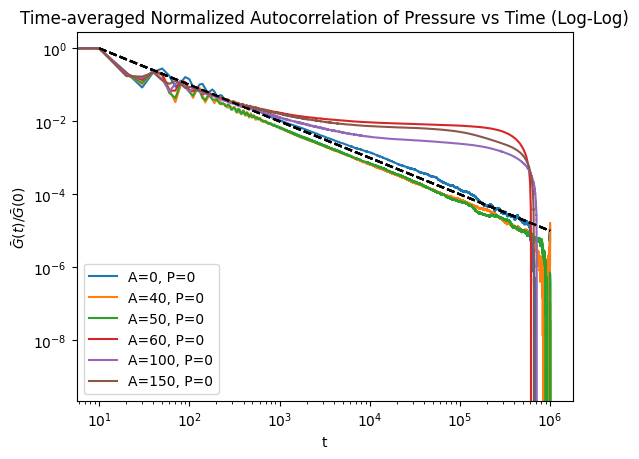

In [4]:
# time average of autocorrelation for different parameters
import matplotlib.pyplot as plt
import pandas as pd

P_values=[0]
patch_A_strengths=[0, 40, 50, 60, 100, 150]

for P in P_values:
    for patch_A_strength in patch_A_strengths:
        file = f"logs/press_{patch_A_strength}_{P}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
    
        overline_G, time = overline_G_func(data['pxx'], data['pyy'], data['pzz'], data['pxy'], data['pxz'], data['pyz'], data['timestep'])

        # log log plot
        plt.loglog(time, overline_G, label=f'A={patch_A_strength}, P={P}')
        # add 1/t line for reference
        plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel(r'$\bar G(t)/\bar G(0)$')
        # plt.ylim(1e-6, 10)
        plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
        plt.legend()
    plt.show()

# file = f"logs/press_50_87.dat"
# data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
# print(data.head())
# # calculate time correlation of pxy

# overline_G, time = overline_G_func(data['pxx'], data['pyy'], data['pzz'], data['pxy'], data['pxz'], data['pyz'], data['timestep'])

# # log log plot
# plt.loglog(time, overline_G, label=f'A=50, P=87')
# # add 1/t line for reference
# plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
# plt.legend()
# plt.xlabel('t')
# plt.ylabel(r'$\bar G(t)/\bar G(0)$')
# # plt.ylim(1e-6, 10)
# plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
# plt.legend()
# plt.show()

[ 1.07385556e+01  1.98004820e+01 -1.59839966e+01  2.55500450e+01
 -2.03012495e+01 -2.02284184e+01  1.97562354e+00 -1.26323444e+01
 -3.60053090e+01  8.06650348e+00 -1.12205193e+01  2.90734687e+01
  1.68728197e+01 -1.94087212e+01 -2.46069090e+01 -6.51133134e-01
 -2.82885933e+01 -1.60125146e+01 -1.66711022e+01  8.83381070e+00
  6.01399946e+00  1.88711036e+01 -1.69671317e+01 -4.44420659e+01
  2.95667122e+01 -2.62200742e+00 -3.36067653e+01 -3.69839656e+01
 -1.07819473e+01  2.51130305e+01 -6.70050054e+00 -3.60614960e+01
  1.73669244e+01 -2.51018367e+01 -7.07411550e-02 -2.97494100e+00
  7.74552608e+00  4.72925328e+01 -1.51081640e+01 -1.90739778e+01
  3.40009674e+01  1.98039610e+01  5.19340896e+00  7.63968887e+00
 -4.03420638e+01  3.11221332e+01 -1.71301276e+00  1.40091020e+01
 -2.87704239e+01  1.95308403e+00  3.23950094e+01 -1.00069113e+01
  2.59538437e+01 -3.91364396e+01 -2.58880188e+01  1.57914935e+01
  1.01379482e+01  6.37101568e+00  3.30738944e+01 -4.69028610e+01
  1.77284806e+01 -1.72459

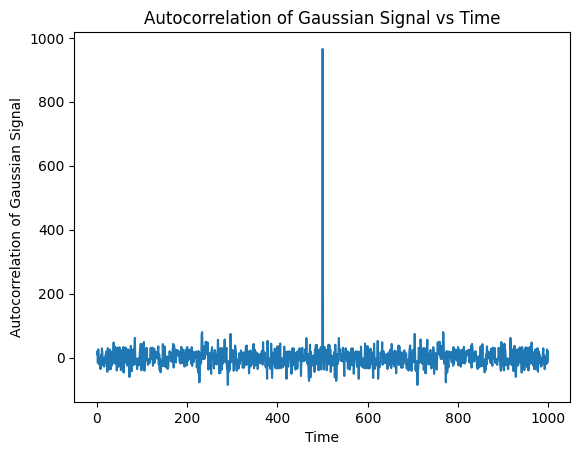

In [11]:
dist = np.random.normal(size=1000)
# plt.plot(dist)
# plt.xlabel('Time')
# plt.ylabel('Gaussian Signal')
# plt.title('Gaussian Signal vs Time')
# plt.show()

auto_corr_1 = np.correlate(dist - np.mean(dist), dist - np.mean(dist), mode='full')
corr = auto_corr_1[auto_corr_1.size // 2:] / np.arange(len(dist), 0, -1)

auto_corr_2 = np.correlate(dist - np.mean(dist), dist - np.mean(dist), mode='same')
# corr = auto_corr
print(auto_corr_2)
# plt.plot(corr)
plt.plot(auto_corr_2)
plt.xlabel('Time')
plt.ylabel('Autocorrelation of Gaussian Signal')
plt.title('Autocorrelation of Gaussian Signal vs Time')
plt.show()

/tmp/ipykernel_367021/2871028673.py:20: RuntimeWarning: divide by zero encountered in divide
  overline_G = np.cumsum(corr) * dt / time
/tmp/ipykernel_367021/132894327.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')


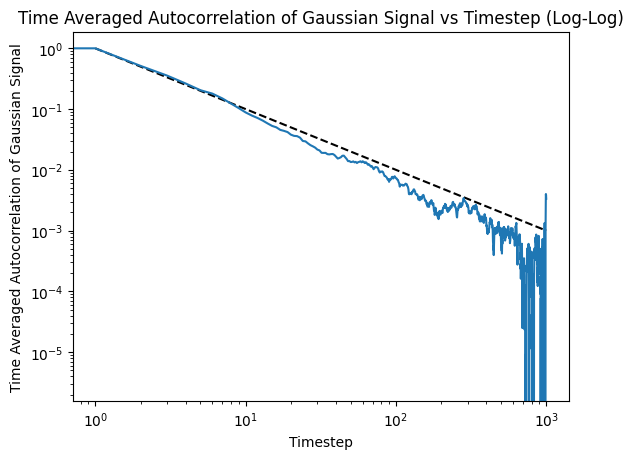

In [ ]:
overline_G, time = overline_G_func(dist, np.arange(len(dist)), window_size=10)

plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
plt.loglog(time, overline_G)
plt.xlabel('Timestep')
plt.ylabel('Time Averaged Autocorrelation of Gaussian Signal')
plt.title('Time Averaged Autocorrelation of Gaussian Signal vs Timestep (Log-Log)')
plt.show()

    time      px_y      px_z      py_z       pxy       pxz       pyz
0  0.000  0.002509  0.002643  0.002240  0.000579  0.000543  0.000546
1  0.001  0.002486  0.002621  0.002217  0.000573  0.000537  0.000540
2  0.002  0.002420  0.002554  0.002150  0.000556  0.000521  0.000523
3  0.003  0.002310  0.002445  0.002041  0.000528  0.000493  0.000496
4  0.004  0.002161  0.002295  0.001890  0.000491  0.000456  0.000459
-22.807210666666666 37.11198293333333


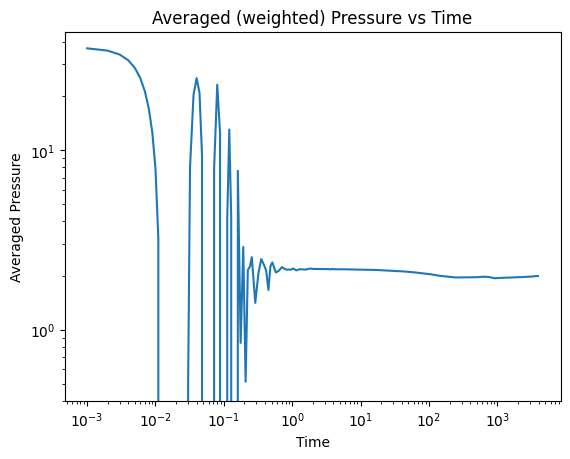

In [42]:
file = f"long_corr.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])

start = 1

ave_press = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
            (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

ave_press *= 40**3 / (1.0 * 1.0)  # V / (kB * T)

print(data.head())
print(ave_press.min(), ave_press.max())
plt.loglog(data['time'][start:], ave_press[start:])
plt.xlabel('Time')
plt.ylabel('Averaged Pressure')
plt.title('Averaged (weighted) Pressure vs Time')
plt.show()

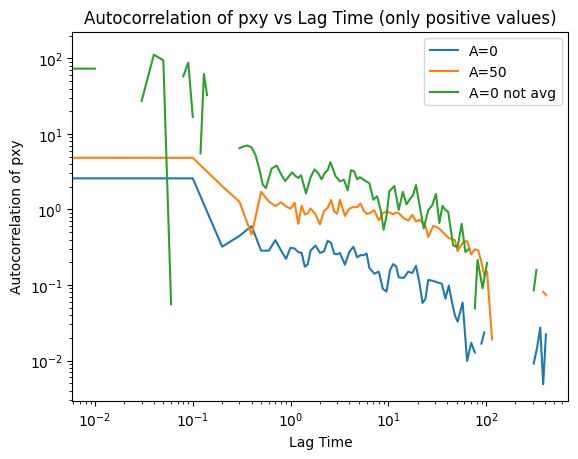

In [ ]:
# import multipletau

# file = "logs/press_50_0.dat"
# data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
# # print(data.head())

# pxy = data['pxy'].values
# time = data['timestep'].values * 0.001

# corr = np.correlate(pxy - np.mean(pxy), pxy - np.mean(pxy), mode='full')[len(pxy)-1:] / np.arange(len(pxy), 0, -1)
# # corr = multipletau.autocorrelate(pxy - np.mean(pxy), deltat=0.001 * 10)    # timestep 0.001, output every 10 steps
# print(corr)
# # plt.plot(corr[:,0], corr[:,1])
# plt.plot(time, corr)
# plt.xlabel('Lag Time')
# plt.ylabel('Autocorrelation of pxy')
# plt.title('Autocorrelation of pxy vs Lag Time')
# # plt.show()


import multipletau

energy_A = [0, 50]
for ea in energy_A:
    file = f"logs/press_{ea}_0.dat"
    data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
    pxx = data['pxy'].values

    corr = multipletau.autocorrelate(pxx - np.mean(pxx), deltat=0.001 * 100)   # timestep 0.001, output every 100 steps

    t = corr[:, 0]
    G = corr[:, 1]

    G  = np.ma.masked_where(G <= 0, G)
    t  = np.ma.masked_where(G <= 0, t)
    # print(corr)
    plt.loglog(t, G, label=f'A={ea}')
file = f"logs/press_0_0_notavg.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxy'].values

corr = multipletau.autocorrelate(pxx - np.mean(pxx), deltat=0.001 * 10)   # timestep 0.001, output every 100 steps

t = corr[:, 0]
G = corr[:, 1]

G  = np.ma.masked_where(G <= 0, G)
t  = np.ma.masked_where(G <= 0, t)

# print(corr)
plt.loglog(t, G, label=f'A={0} not avg')
# plt.loglog(corr[:,0], -corr[:,1])
# plt.plot(corr)
plt.xlabel('Lag Time')
plt.ylabel('Autocorrelation of pxy')
plt.legend()
plt.title('Autocorrelation of pxy vs Lag Time (only positive values)')
plt.show()

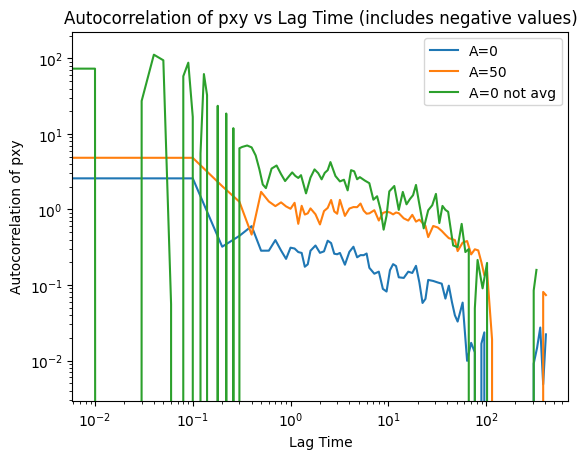

In [ ]:
import multipletau

energy_A = [0, 50]
for ea in energy_A:
    file = f"logs/press_{ea}_0.dat"
    data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
    pxx = data['pxy'].values

    corr = multipletau.autocorrelate(pxx - np.mean(pxx), deltat=0.001 * 100)   # timestep 0.001, output every 100 steps

    t = corr[:, 0]
    G = corr[:, 1]
    # print(corr)
    plt.loglog(t, G, label=f'A={ea}')
file = f"logs/press_0_0_notavg.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxy'].values

corr = multipletau.autocorrelate(pxx - np.mean(pxx), deltat=0.001 * 10)   # timestep 0.001, output every 100 steps

t = corr[:, 0]
G = corr[:, 1]

# print(corr)
plt.loglog(t, G, label=f'A={0} not avg')
# plt.loglog(corr[:,0], -corr[:,1])
# plt.plot(corr)
plt.xlabel('Lag Time')
plt.ylabel('Autocorrelation of pxy')
plt.legend()
plt.title('Autocorrelation of pxy vs Lag Time (includes negative values)')
plt.show()

In [ ]:
file = f"logs/press_0_0_notavg.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxy'].values

mean, std_dev = np.mean(pxx), np.std(pxx)
print(f"Not Averaging: Mean: {mean}, Standard Deviation: {std_dev}")

file = f"logs/press_0_0.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxy'].values

mean, std_dev = np.mean(pxx), np.std(pxx)
print(f"Averaging: Mean: {mean}, Standard Deviation: {std_dev}")

Not Averaging: Mean: 0.000472051976848, Standard Deviation: 0.05219109061569378
Averaging: Mean: 0.00047337834736947405, Standard Deviation: 0.03322043027544048


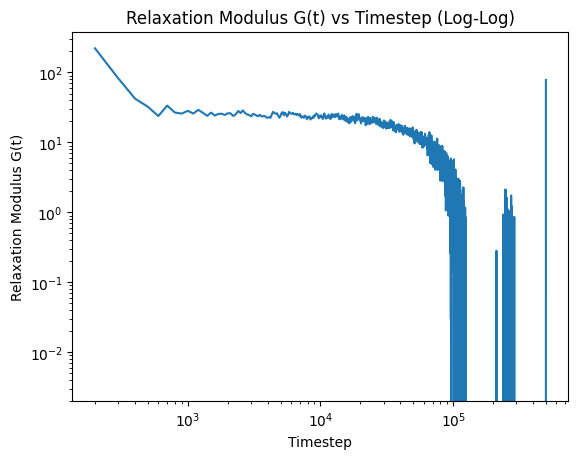

In [ ]:
import multipletau

file = "logs/press_0_0.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
# print(data.head())

pxx = data['pxy'].values
G_t, time = G_func(data['pxx'], data['pyy'], data['pzz'], data['pxy'], data['pxz'], data['pyz'], data['timestep'])

# overline_G = np.cumsum(G_t) * (time[1] - time[0]) / time
# overline_G[0] = overline_G[1]  # avoid division by zero
# overline_G /= overline_G[0]  # normalize by G(0)

plt.loglog(time, G_t)
# plt.loglog(time, overline_G)
plt.xlabel('Timestep')
plt.ylabel('Relaxation Modulus G(t)')
plt.title('Relaxation Modulus G(t) vs Timestep (Log-Log)')
plt.show()


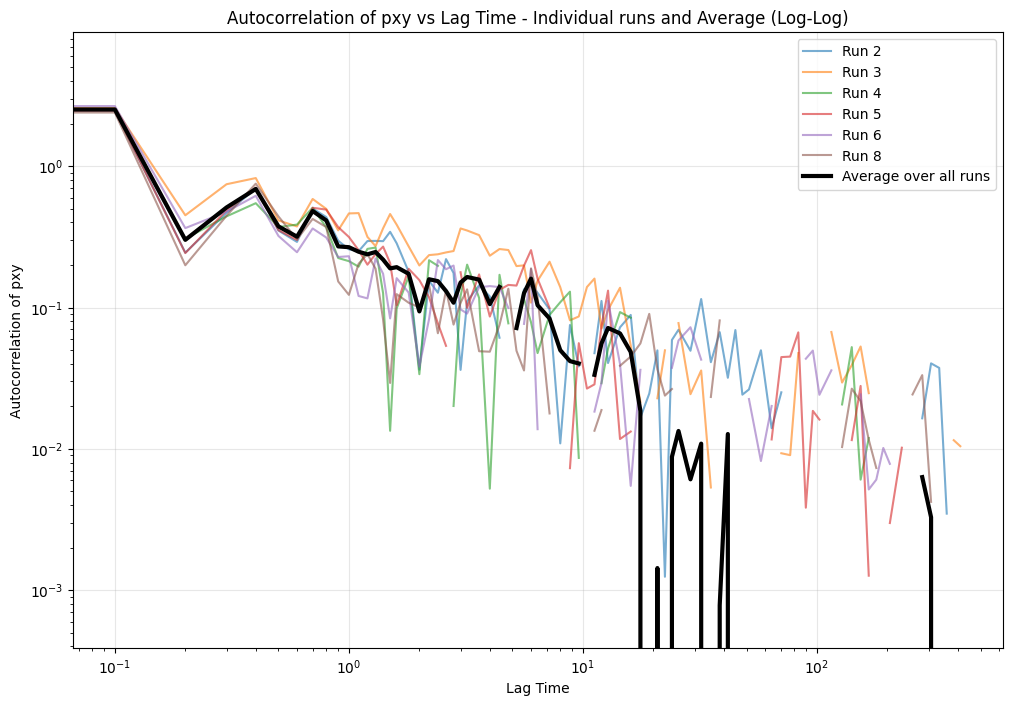

In [ ]:
import multipletau
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

indices = [2, 3, 4, 5, 6, 8]

# Dictionary to store all correlation arrays
all_correlations = {}
all_times = {}

# Process each file and store the correlation data
for i in indices:
    f = f"logs/press_0_0_{i}.dat"
    data = pd.read_csv(f, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])

    pxx = data['pxy'].values

    corr = multipletau.autocorrelate(pxx - np.mean(pxx), deltat=0.001 * 100)   # timestep 0.001, output every 10 steps
    
    t = corr[:, 0]
    G = corr[:, 1]

    G  = np.ma.masked_where(G <= 0, G)
    t  = np.ma.masked_where(G <= 0, t)

    # Store time and correlation data
    all_times[i] = t
    all_correlations[i] = G

# Plot individual correlation functions
plt.figure(figsize=(12, 8))

# Plot each individual correlation
for i in indices:
    plt.loglog(all_times[i], all_correlations[i], alpha=0.6, label=f'Run {i}')

# Calculate and plot the average
# Find the common time grid (use the shortest one to ensure all data exists)
min_length = min(len(all_correlations[i]) for i in indices)

# Truncate all arrays to the same length and calculate average
truncated_correlations = np.array([all_correlations[i][:min_length] for i in indices])
avg_G = np.mean(truncated_correlations, axis=0)
t = all_times[indices[0]][:min_length]  # Use time from first run

plt.loglog(t, avg_G, 'k-', linewidth=3, label='Average over all runs')

plt.xlabel('Lag Time')
plt.ylabel('Autocorrelation of pxy')
plt.title('Autocorrelation of pxy vs Lag Time - Individual runs and Average (Log-Log)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Long time + larger box


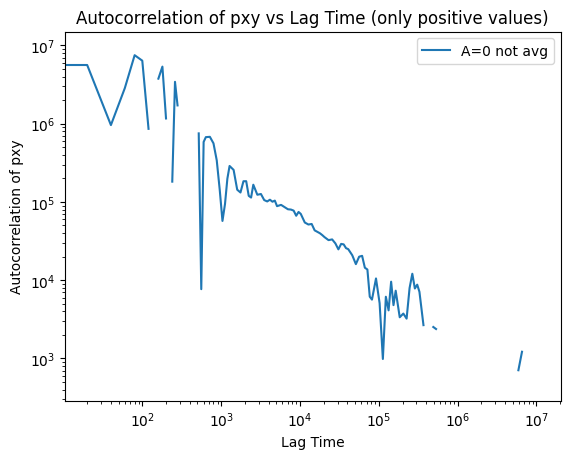

In [33]:
import multipletau
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

file = f"logs/press_0_0_100.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxy'].values

# average pxy over every 10 steps
binsize = 10
# pxy = np.convolve(pxy, np.ones(binsize)/binsize, mode='valid')

# corr = multipletau.autocorrelate(pxx - np.mean(pxx), m=60, deltat=0.001 * 10)   # timestep 0.001, output every 100 steps

# t = corr[:, 0]
# G = corr[:, 1]

corr = G_func(data['pxx'], data['pyy'], data['pzz'], data['pxy'], data['pxz'], data['pyz'], data['timestep'], multitau=True)    
t = corr[1]
G = corr[0]


G  = np.ma.masked_where(G <= 0, G)
t  = np.ma.masked_where(G <= 0, t)

# print(corr)
plt.loglog(t, G, label=f'A={0} not avg')
# plt.loglog(corr[:,0], -corr[:,1])
# plt.plot(corr)
plt.xlabel('Lag Time')
plt.ylabel('Autocorrelation of pxy')
# plt.ylim(1e-6, 1e3)
# plt.xlim(1e-2, 1e3)
plt.legend()
plt.title('Autocorrelation of pxy vs Lag Time (only positive values)')
plt.show()

Looking for any periodic artifacts in p_xy

50000


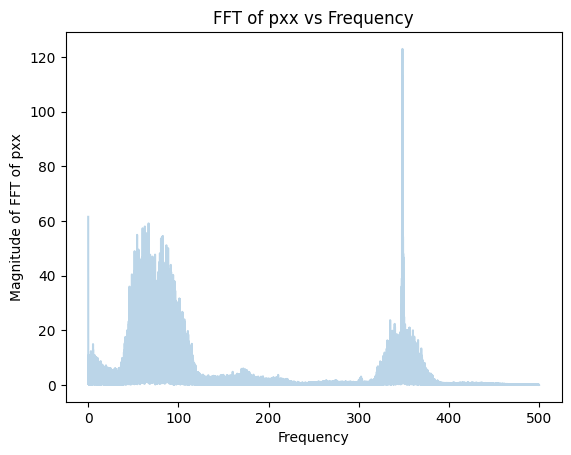

In [25]:
import multipletau
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

file = f"logs/press_test_freq.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
pxx = data['pxx'].values
print(len(pxx))

pxx = np.pad(pxx, (0, 2**20 - len(pxx)), 'constant', constant_values=(0, 0))
fourier_transform = np.fft.fft(pxx - np.mean(pxx))
frequencies = np.fft.fftfreq(len(pxx), d=0.001)
magnitude = np.abs(fourier_transform)

plt.plot(frequencies[1:len(frequencies)//2], magnitude[1:len(magnitude)//2], label='test (damping param = 100)', alpha=0.3)
plt.xlabel('Frequency')
plt.ylabel('Magnitude of FFT of pxx')
plt.title('FFT of pxx vs Frequency')


# file = f"logs/press_0_0_long.dat"
# data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'pxx', 'pyy', 'pzz', 'pxy', 'pxz', 'pyz'])
# pxx = data['pxx'].values
# print(len(pxx))

# pxx = np.pad(pxx, (0, 2**20 - len(pxx)), 'constant', constant_values=(0, 0))


# fourier_transform = np.fft.fft(pxx - np.mean(pxx))
# frequencies = np.fft.fftfreq(len(pxx), d=0.001)
# magnitude = np.abs(fourier_transform)

# plt.plot(frequencies[1:len(frequencies)//2], magnitude[1:len(magnitude)//2], label='test (damping param = 200)', alpha=0.3)
# plt.xlabel('Frequency')
# plt.ylabel('Magnitude of FFT of pxx')
# plt.title('FFT of pxx vs Frequency')
# plt.ylim(0, 4e3)
# plt.legend()
plt.show()